In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#Load Auto MPG dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

#Display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [7]:
# separate input and output
X=df[['displacement']]
Y=df['mpg']
#Check missing values
print("Missing values in displacement:",X.isnull().sum())
print("Mssing values in mpg:",Y.isnull().sum())


Missing values in displacement: displacement    0
dtype: int64
Mssing values in mpg: 0


In [10]:
#Remove rows containing missing values
data=df[['displacement','mpg']].dropna()

#Update input and output
X=data[['displacement']]
Y=data['mpg']

#display selected data
print("Feature:")
print(X.head())

print("\nTarget:")
print(Y.head())


Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


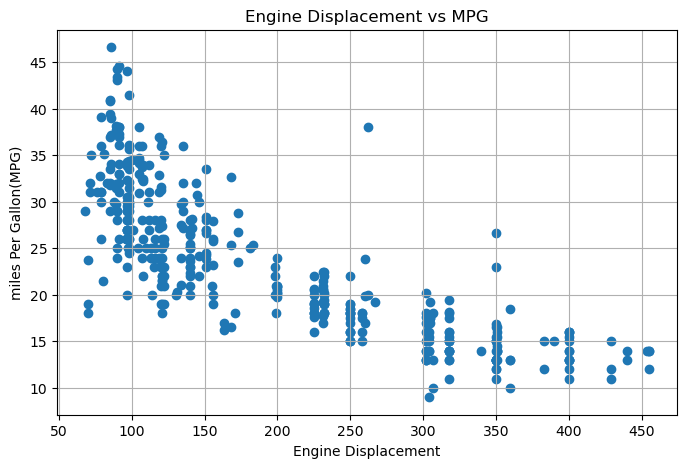

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(X,Y)

plt.xlabel("Engine Displacement")
plt.ylabel("miles Per Gallon(MPG)")
plt.title("Engine Displacement vs MPG")

plt.grid(True)
plt.show()

In [15]:
#split dataset
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training samples:",len(X_train))
print("testing samples:",len(X_test))

Training samples: 318
testing samples: 80


In [20]:
#create linear regression model
linear_model=LinearRegression()

# Train the model
linear_model.fit(X_train,Y_train)
#predict on test data
Y_pred_linear=linear_model.predict(X_test)

#predict on test data
Y_pred_linear=linear_model.predict(X_test)

#calculate MSE
mse_linear=mean_squared_error(Y_test,Y_pred_linear)

#Calculate R-squared
r2_linear=r2_score(Y_test,Y_pred_linear)

print("linear regression results")
print("-------------------------")
print("MSE:",mse_linear)
print("r-squared:",r2_linear)


linear regression results
-------------------------
MSE: 18.102543998358946
r-squared: 0.6633114869465595


In [27]:
#Store results
results=[]
#Store polynomial models for plotting
polynomial_models={}
#Add Linear Regression results
results.append({
    'Model':'Linear Regrssion',
    'Degree':1,
    'MSE':mse_linear,
    'R_squared':r2_linear
})

#try polynomial degrees from 2 to  5
for degree in range(2,6):
    #Create polynomial features
    poly=PolynomialFeatures(degree=degree)

    #Transform training and testing data
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.fit_transform(X_test)

    #create Linear regression model
    poly_model=LinearRegression()
    #Train polynomial regression model
    poly_model.fit(X_train_poly,Y_train)

    #make predictions
    Y_pred_poly=poly_model.predict(X_test_poly)

    #calculate evaluation metrices

    mse=mean_squared_error(Y_test,Y_pred_poly)
    r2=r2_score(Y_test,Y_pred_poly)

    #Store results
    results.append({
        'Model':'Polynomial Regression',
        'Degree':degree,
        'MSE':mse,
        'R-squared':r2

    })
    #Store model and polynomial tranformer
    polynomial_models[degree]={
        'poly':poly,
        'model':poly_model,

    }
    

In [29]:
#Convert
results_df=pd.DataFrame(results)
results_df

,Model,Degree,MSE,R_squared,R-squared
0,Linear Regrssion,1,18.102544,0.663311,NaN
1,Polynomial Regression,2,15.107354,NaN,0.719019
2,Polynomial Regression,3,14.943632,NaN,0.722064
3,Polynomial Regression,4,14.961487,NaN,0.721732
4,Polynomial Regression,5,15.230896,NaN,0.716721


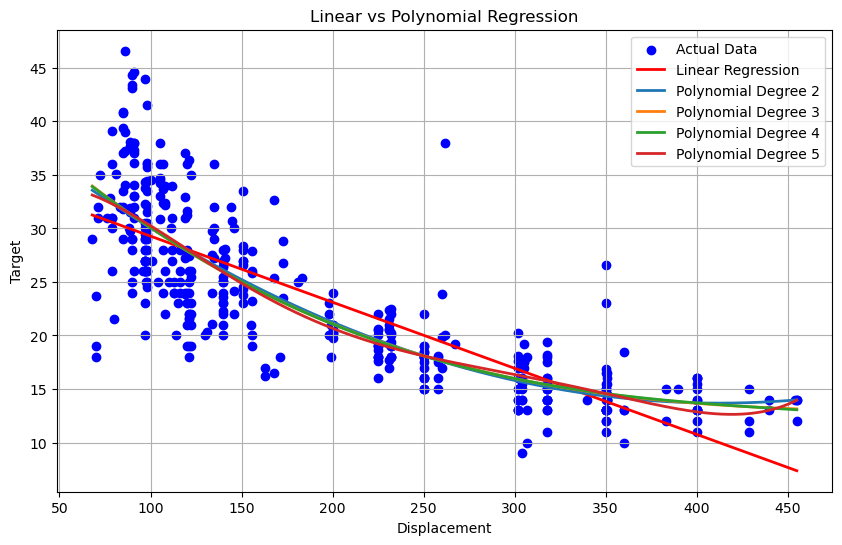

In [42]:
# Create smooth X values for plotting
X_plot = pd.DataFrame({
    'displacement': np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300
    )
})

# Create figure
plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(
    X['displacement'],
    Y,
    label='Actual Data',
    color='blue'
)

# Plot Linear Regression
Y_plot_linear = linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    Y_plot_linear,
    color='red',
    linewidth=2,
    label='Linear Regression'
)

# Plot Polynomial Regression
for degree in range(2, 6):

    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    # Transform plotting data
    X_plot_poly = poly.transform(X_plot)

    # Predict
    Y_plot_poly = poly_model.predict(X_plot_poly)

    # Plot polynomial curve
    plt.plot(
        X_plot['displacement'],
        Y_plot_poly,
        linewidth=2,
        label=f'Polynomial Degree {degree}'
    )

# Labels and title
plt.xlabel('Displacement')
plt.ylabel('Target')
plt.title('Linear vs Polynomial Regression')

plt.legend()
plt.grid(True)
plt.show()

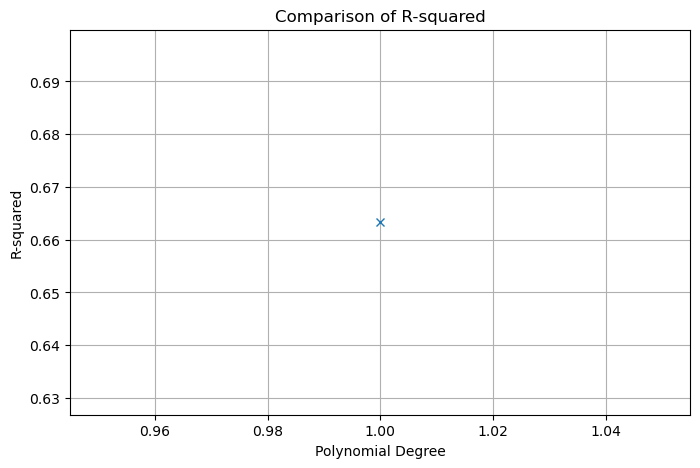

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Degree'],
    results_df['R_squared'],
    marker='x',
    
)

plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared')
plt.title('Comparison of R-squared')
plt.grid(True)

plt.show()   

In [ ]:
plt.figure(figsize=(8,5))
bars=plt.bar(results_df['Degreee'].astype(str),results_df['MSE'})
plt.bar_label(bars,fmt='%.2f',padding=3)
